<a href="https://colab.research.google.com/github/MonaliM5/cardio_risk_prediction/blob/main/notebooks/Cardiovascular_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Cardiovascular Risk Prediction



##### **Project Type -**     Classification
##### **Contribution -**     Individual
##### **Student Name -**     Monali Vijay Mhaske

# **Project Summary -**

* Cardiovascular diseases are among the leading causes of death worldwide, making early risk detection a crucial public health priority.

* This project aims to develop a data-driven, machine-learning-based classification model that predicts whether an individual is at risk of cardiovascular disease using routinely collected clinical and demographic information.

* The study will begin with detailed Exploratory Data Analysis (EDA) to identify patterns and correlations between health indicators such as age, blood pressure, cholesterol, glucose levels, and lifestyle factors.

* Subsequently, relevant features will be engineered and multiple classification algorithms—including Logistic Regression, Random Forest, and XGBoost—will be applied to build predictive models.

* The performance of these models will be evaluated using metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC, followed by cross-validation and hyperparameter tuning to improve robustness.

* The final deliverable will be an explainable and deployment-ready notebook that highlights the most influential factors contributing to cardiovascular risk, thereby supporting early intervention and better clinical decision-making.


# **GitHub Link -**

https://github.com/MonaliM5/cardio_risk_prediction/tree/main

# **Problem Statement**


* Cardiovascular diseases (CVDs) continue to be one of the most significant causes of mortality globally, often resulting from undetected or poorly managed risk factors such as hypertension, obesity, high cholesterol, and unhealthy lifestyle habits.

* Early detection of individuals who are at high risk can play a vital role in preventing severe cardiac events and reducing healthcare costs.

* The challenge addressed in this project is to build a predictive model that can accurately classify whether a person is at risk of developing cardiovascular disease based on easily measurable clinical and demographic features.

* The dataset includes attributes such as age, gender, blood pressure, cholesterol, glucose levels, smoking and alcohol habits, physical activity, and body mass index (BMI).

* By leveraging supervised machine learning algorithms, the goal is to create a robust, interpretable, and deployment-ready model that assists healthcare practitioners and organizations in identifying high-risk patients early.

* Such a model can help design personalized prevention programs, prioritize medical screenings, and ultimately contribute to improving population health outcomes.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

# importing core libraries for data manipulation and computation
import numpy as np
import pandas as pd

# importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# importing machine learning algorithms and utilities
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# importing evaluatoin metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# importing additional tools
import warnings
warnings.filterwarnings('ignore')  # ignoring unnecessary warnings for clean output

# setting global plot aesthetics for consistency
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (8, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Dataset Loading

In [2]:
# Load Dataset
# 1️⃣ Removing any previous half-cloned folders
!rm -rf cardio-risk-prediction

# 2️⃣ Clonning the repository freshly
!git clone https://github.com/MonaliM5/cardio_risk_prediction.git

# 3️⃣ Moving into your project directory
%cd cardio_risk_prediction

# 4️⃣ Verifying that the dataset exists
!ls data/raw

Cloning into 'cardio_risk_prediction'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 216 (delta 47), reused 11 (delta 9), pack-reused 135 (from 2)
Receiving objects: 100% (216/216), 859.42 KiB | 13.86 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/cardio_risk_prediction
data_cardiovascular_risk.csv


In [3]:
# Loading the dataset
df = pd.read_csv("data/raw/data_cardiovascular_risk.csv")
print("✅ Dataset loaded successfully!")


✅ Dataset loaded successfully!


### Dataset First View

In [4]:
# Dataset First Look
# displaying the first few records to understand the data structure
# Sales Dataset First Look
print("Dataset First View ")
df.head()

Dataset First View 


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(f"Dataset -\nRows Count : {df.shape[0]}  \tColumns Count : {df.shape[1]}")

Dataset -
Rows Count : 3390  	Columns Count : 17


### Dataset Information

In [6]:
# Dataset Info
print("Data Information:")
df.info()

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
d

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
# Checking the number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows in the dataset: {duplicate_count}")

Number of duplicate rows in the dataset: 0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
# checking missing values in each column

print("Missing values count per column:")
df.isnull().sum()

Missing values count per column:


,0
id,0
age,0
education,87
sex,0
is_smoking,0
cigsPerDay,22
BPMeds,44
prevalentStroke,0
prevalentHyp,0
diabetes,0


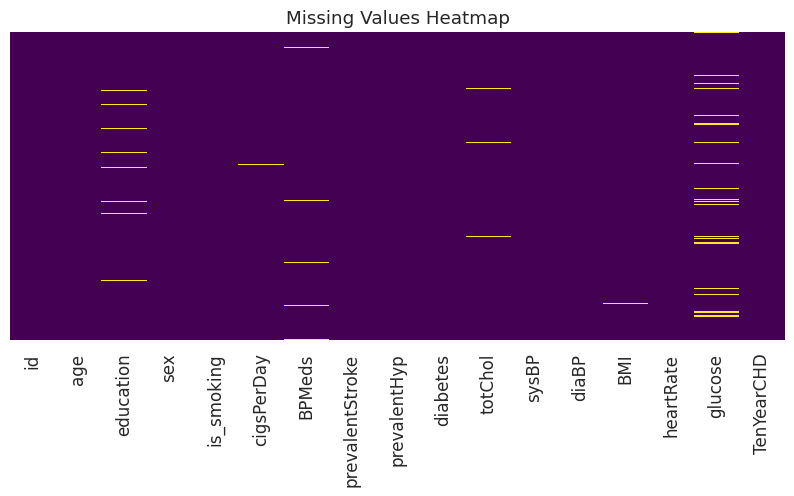

In [9]:
# Visualizing the missing values
# visualizing missing values using heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

* From the initial data exploration and quality checks, several important insights about the dataset were observed.

* The dataset represents real-world clinical and demographic information of individuals, where each row corresponds to a patient record and each column captures a specific health, lifestyle, or medical attribute.

* It includes a balanced mix of demographic factors (age, sex, education), lifestyle indicators (smoking status, cigarette consumption, physical activity), and clinical measurements (blood pressure, cholesterol, glucose, BMI, heart rate).

* The target variable `TenYearCHD` indicates whether an individual is at risk of developing coronary heart disease within the next ten years, making this a supervised binary classification problem.

* Key observations from the dataset include:

  - The data contains both continuous and categorical variables, requiring appropriate preprocessing techniques before modeling.

  - Several medically relevant features such as glucose, cholesterol, BMI, and blood pressure are present, which are known risk factors for cardiovascular disease.

  - Missing values are present in some biochemical and lifestyle-related features, reflecting realistic challenges commonly encountered in healthcare datasets.

  - No duplicate records were found, indicating good data collection quality.

* Overall, the dataset is rich, clinically meaningful, and suitable for building a predictive machine learning model after proper data cleaning and feature engineering.

* The presence of real-world imperfections such as missing values enhances the practical relevance of this project.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
# Printing list of columns in Sales Dataset
print("Columns in Dataset:\n")
print(df.columns.tolist())

Columns in Dataset:

['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [11]:
# Dataset Describe
# Describing the Sales Dataset
print("Data Description : \n")
display(df.describe())

Data Description : 



,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3390.000000,3390.000000,3303.000000,3368.000000,3346.000000,3390.000000,3390.000000,3390.000000,3352.000000,3390.00000,3390.000000,3376.000000,3389.000000,3086.000000,3390.000000
mean,1694.500000,49.542183,1.970936,9.069477,0.029886,0.006490,0.315339,0.025664,237.074284,132.60118,82.883038,25.794964,75.977279,82.086520,0.150737
std,978.753033,8.592878,1.019081,11.879078,0.170299,0.080309,0.464719,0.158153,45.247430,22.29203,12.023581,4.115449,11.971868,24.244753,0.357846
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.50000,48.000000,15.960000,45.000000,40.000000,0.000000
25%,847.250000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.00000,74.500000,23.020000,68.000000,71.000000,0.000000
50%,1694.500000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.50000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,2541.750000,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,144.00000,90.000000,28.040000,83.000000,87.000000,0.000000
max,3389.000000,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.00000,142.500000,56.800000,143.000000,394.000000,1.000000


### Variables Description

Understanding the meaning and role of each variable is essential before performing exploratory data analysis and model building. This helps in selecting appropriate preprocessing techniques, choosing relevant features, and interpreting model outputs correctly.

Below is a brief description of the variables present in the dataset:

**Demographic Variables**
- **id**: Unique identifier for each patient.
- **age**: Age of the individual (in years).
- **sex**: Gender of the individual (binary encoded).
- **education**: Education level of the individual, representing socioeconomic status.

**Lifestyle Variables**
- **is_smoking**: Indicates whether the individual is a smoker.
- **cigsPerDay**: Average number of cigarettes smoked per day.
- **BPMeds**: Indicates whether the individual is on blood pressure medication.
- **prevalentStroke**: Indicates whether the individual has previously experienced a stroke.
- **prevalentHyp**: Indicates whether the individual has hypertension.
- **diabetes**: Indicates whether the individual has diabetes.

**Clinical and Physiological Variables**
- **totChol**: Total cholesterol level in the blood.
- **sysBP**: Systolic blood pressure.
- **diaBP**: Diastolic blood pressure.
- **BMI**: Body Mass Index, representing body fat based on height and weight.
- **heartRate**: Resting heart rate of the individual.
- **glucose**: Blood glucose level.

**Target Variable**
- **TenYearCHD**: Target variable indicating whether the individual is at risk of developing coronary heart disease within the next ten years (1 = at risk, 0 = not at risk).

Overall, the dataset contains a comprehensive set of variables that are clinically relevant and well-aligned with cardiovascular risk prediction. These variables collectively capture demographic, behavioral, and physiological factors that contribute to heart disease risk.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

# ============================================================
# 🔢 Checking Unique Values for Each Variable
# ============================================================

# Iterating through each column to check unique values
for column in df.columns:
    print(f"\nColumn Name: {column}")
    print(f"Number of unique values: {df[column].nunique()}")
    print(f"Unique values: {df[column].unique()}")


Column Name: id
Number of unique values: 3390
Unique values: [   0    1    2 ... 3387 3388 3389]

Column Name: age
Number of unique values: 39
Unique values: [64 36 46 50 61 41 55 53 43 44 58 51 56 42 38 63 35 54 62 47 34 39 59 45
 49 60 40 52 48 37 65 57 68 67 33 66 69 70 32]

Column Name: education
Number of unique values: 4
Unique values: [ 2.  4.  1.  3. nan]

Column Name: sex
Number of unique values: 2
Unique values: ['F' 'M']

Column Name: is_smoking
Number of unique values: 2
Unique values: ['YES' 'NO']

Column Name: cigsPerDay
Number of unique values: 32
Unique values: [ 3.  0. 10. 20. 30. 35. 40. 15.  9. 60. 17. 25.  5. 43.  7. 50. 19. 18.
  1. 45.  2.  6. nan 11.  8.  4. 14. 16. 23. 13. 12. 70. 38.]

Column Name: BPMeds
Number of unique values: 2
Unique values: [ 0. nan  1.]

Column Name: prevalentStroke
Number of unique values: 2
Unique values: [0 1]

Column Name: prevalentHyp
Number of unique values: 2
Unique values: [0 1]

Column Name: diabetes
Number of unique values: 2


## ***3. Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

# ============================================================
# 🧹 DATA WRANGLING – DOMAIN-AWARE & EXPERT IMPLEMENTATION
# ============================================================

# creating a working copy to preserve original dataset
df_wrangle = df.copy()

# ------------------------------------------------------------
# 1. Encoding Categorical Binary Variables
# ------------------------------------------------------------

# encoding sex column (M = 1, F = 0)
if df_wrangle['sex'].dtype == 'object':
    df_wrangle['sex'] = df_wrangle['sex'].map({'M': 1, 'F': 0})


# encoding smoking status (YES = 1, NO = 0)
if df_wrangle['is_smoking'].dtype == 'object':
    df_wrangle['is_smoking'] = df_wrangle['is_smoking'].map({'YES': 1, 'NO': 0})




# ------------------------------------------------------------
# 2. Handling Missing Values – Column-wise Strategy
# ------------------------------------------------------------

# 2.1 Education (Ordinal categorical) → Mode imputation
df_wrangle['education'].fillna(df_wrangle['education'].mode()[0], inplace=True)
df_wrangle['education'] = df_wrangle['education'].astype(int)


# 2.2 Cigarettes per day → Conditional imputation
# Non-smokers → 0 cigarettes
df_wrangle.loc[df_wrangle['is_smoking'] == 0, 'cigsPerDay'] = 0


# Smokers → median cigarettes (rounded)
smoker_median = df_wrangle.loc[
    (df_wrangle['is_smoking'] == 1) & (df_wrangle['cigsPerDay'].notnull()),
    'cigsPerDay'
].median()

df_wrangle.loc[
    (df_wrangle['is_smoking'] == 1) & (df_wrangle['cigsPerDay'].isnull()),
    'cigsPerDay'
] = round(smoker_median)

df_wrangle['cigsPerDay'] = df_wrangle['cigsPerDay'].astype(int)



# 2.3 BP Medications (Binary) → Mode imputation
df_wrangle['BPMeds'].fillna(df_wrangle['BPMeds'].mode()[0], inplace=True)
df_wrangle['BPMeds'] = df_wrangle['BPMeds'].astype(int)



# 2.4 Total Cholesterol → Median (integer)
df_wrangle['totChol'].fillna(round(df_wrangle['totChol'].median()), inplace=True)
df_wrangle['totChol'] = df_wrangle['totChol'].astype(int)



# 2.5 BMI → Median (float)
df_wrangle['BMI'].fillna(df_wrangle['BMI'].median(), inplace=True)



# 2.6 Heart Rate → Median (integer)
df_wrangle['heartRate'].fillna(round(df_wrangle['heartRate'].median()), inplace=True)
df_wrangle['heartRate'] = df_wrangle['heartRate'].astype(int)


# 2.7 Glucose → Median (integer)
df_wrangle['glucose'].fillna(round(df_wrangle['glucose'].median()), inplace=True)
df_wrangle['glucose'] = df_wrangle['glucose'].astype(int)





# ------------------------------------------------------------
# 3. Final Validation
# ------------------------------------------------------------

print("✅ Data Wrangling Completed Successfully")
print("Remaining missing values in dataset:", df_wrangle.isnull().sum().sum())
print("Final dataset shape:", df_wrangle.shape)




✅ Data Wrangling Completed Successfully
Remaining missing values in dataset: 0
Final dataset shape: (3390, 17)


### What all manipulations have you done and insights you found?

During the data wrangling stage, several domain-aware preprocessing steps were performed to improve data quality and ensure logical consistency across variables.

Key manipulations performed include:

- Binary categorical variables such as `sex` and `is_smoking` were encoded into numerical format to make them suitable for machine learning models.
- The `education` variable, although stored as a numerical type, represents an ordinal categorical feature. Missing values in this column were imputed using the mode rather than the median to preserve category meaning.
- Missing values in `cigsPerDay` were handled using conditional logic. For non-smokers, missing values were replaced with zero, while for smokers, missing values were imputed using the median number of cigarettes consumed by smokers and then converted to integers to maintain real-world validity.
- Binary clinical indicators such as `BPMeds` were imputed using the most frequent value (mode), as median imputation is not meaningful for binary variables.
- Continuous clinical measurements including `totChol`, `BMI`, `heartRate`, and `glucose` were imputed using median values. Integer-only physiological variables were rounded and type-cast appropriately to maintain clinical realism.
- All transformations were applied on a separate working copy of the dataset to preserve the original data.

Insights gained from data wrangling include:

- Missing values were primarily present in lifestyle-related and biochemical variables, reflecting realistic challenges in healthcare data collection.
- The necessity of column-specific imputation strategies became evident, as different variables required different handling based on their semantic meaning rather than just data type.
- After preprocessing, the dataset contained no missing values and maintained its original structure, making it fully suitable for exploratory data analysis and predictive modeling.

Overall, the data wrangling process resulted in a clean, consistent, and logically sound dataset that accurately represents real-world cardiovascular health information.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Univariate Analysis

##### Chart - 1 Distribution of Target Variable (TenYearCHD)

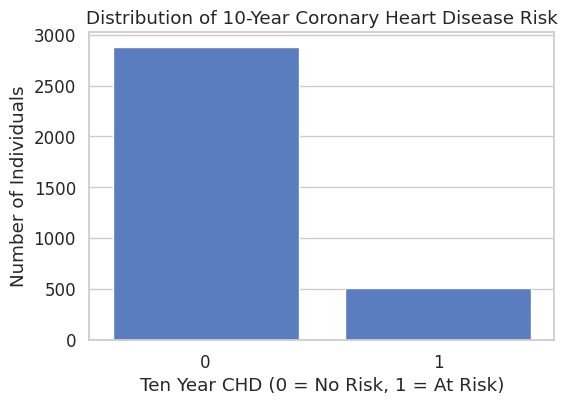

In [14]:
# Chart - 1 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 1
# Visualizing the distribution of the target variable
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals for each class of the target variable
sns.countplot(
    x='TenYearCHD',
    data=df_wrangle
)

# setting the title of the chart to describe the visualization
plt.title('Distribution of 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to explain target class meaning
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* The target variable TenYearCHD defines the core objective of this project—predicting whether an individual is at risk of developing coronary heart disease within the next ten years.

* A count plot is chosen because it clearly shows the frequency distribution of each class in a binary classification problem, helping assess class balance, which directly influences model selection, evaluation strategy, and performance interpretation.

###### 2. What is/are the insight(s) found from the chart?

From the chart, it is clearly observed that:

* The number of individuals not at risk (TenYearCHD = 0) is significantly higher than those at risk (TenYearCHD = 1).

* This indicates a strong class imbalance, where the minority class (at-risk individuals) represents a much smaller portion of the dataset.

* This imbalance suggests that the dataset does not have an equal representation of both outcome classes, which is a common characteristic of real-world healthcare data

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Early identification of class imbalance allows the use of appropriate modeling techniques such as class weighting, resampling methods, or threshold tuning.

* Evaluation metrics like recall, precision, F1-score, and ROC-AUC can be prioritized over accuracy to ensure that high-risk patients are not missed.

* In a healthcare context, correctly identifying at-risk individuals enables early intervention, preventive care, and better allocation of medical resources.


**Potential Negative Impact if Ignored:**

* If class imbalance is ignored, a model may achieve high accuracy by predominantly predicting the majority class while failing to detect high-risk individuals.

* This can result in false negatives, where patients who are actually at risk are classified as low risk, leading to delayed diagnosis and adverse health outcomes.

* Such failures can negatively impact patient safety, healthcare costs, and trust in predictive systems.


**Conclusion :**

* This chart establishes a critical foundation for the project by revealing class imbalance in the target variable.

* Addressing this imbalance appropriately will be essential for building a reliable, clinically meaningful, and ethically responsible cardiovascular risk prediction model.

##### Chart - 2 Distribution of age

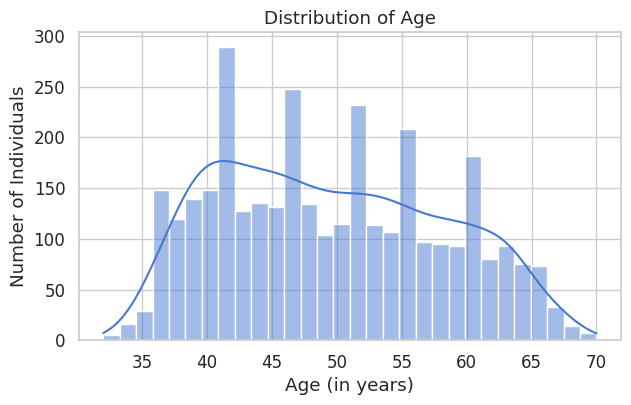

In [15]:
# Chart - 2 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 2
# Visualizing the distribution of age
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of age using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='age',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Age')

# labeling the x-axis to represent age in years
plt.xlabel('Age (in years)')

# labeling the y-axis to represent frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age is a fundamental demographic variable and one of the strongest known risk factors for cardiovascular disease.

* A **histogram with KDE (Kernel Density Estimate)** is chosen because it effectively shows:

  * The overall distribution of age values

  * The concentration of individuals across age ranges

  * The shape, spread, and skewness of the data

* This visualization helps in understanding whether the dataset represents a specific age group disproportionately and whether age-related patterns can influence cardiovascular risk prediction.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution:

* The age values range approximately from the early 30s to around 70 years.

* The dataset shows a higher concentration of individuals between 40 and 60 years, indicating that middle-aged adults are the dominant group.

* The distribution appears slightly right-skewed, with fewer individuals at the extreme higher age range.

* Very young individuals (below 35) and very old individuals (above 65) are underrepresented.

This suggests that the dataset primarily focuses on a middle-aged population, which is a critical age group for cardiovascular risk assessment.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Since cardiovascular risk increases with age, the strong representation of individuals aged 40–60 enhances the model’s ability to learn meaningful age-related risk patterns.

* Healthcare providers can use such models to design age-specific screening and prevention programs targeting middle-aged adults, potentially reducing long-term cardiac events.

**Potential Negative Impact:**

* The underrepresentation of younger and older age groups may limit the model’s generalizability for populations outside the dominant age range.

* Predictions for very young or elderly individuals may be less reliable, which could affect decision-making if the model is applied universally without proper validation.


**Conclusion :**

* The age distribution indicates a dataset focused mainly on middle-aged individuals, aligning well with cardiovascular risk studies.

* However, care must be taken when applying the model to age groups that are sparsely represented.

##### Chart - 3 Distribution of sex

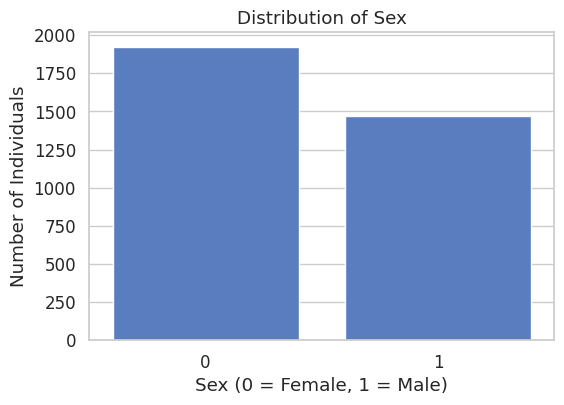

In [16]:
# Chart - 3 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 3
# Visualizing the distribution of sex
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals by sex
sns.countplot(
    x='sex',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Sex')

# labeling the x-axis to represent sex categories
plt.xlabel('Sex (0 = Female, 1 = Male)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()



###### 1. Why did you pick the specific chart?

* Sex is a key demographic variable and an important biological factor influencing cardiovascular risk.

* A count plot is selected because it clearly displays the distribution of categorical binary variables, allowing us to understand whether the dataset is gender-balanced or skewed toward a particular group.

* This understanding is essential before drawing conclusions or building predictive models.

###### 2. What is/are the insight(s) found from the chart?

From the chart, it is observed that:

* The dataset contains more female individuals (sex = 0) than male individuals (sex = 1).

* However, the difference between the two groups is not extreme, indicating a moderately balanced gender distribution.

* Both male and female populations are sufficiently represented, which is beneficial for learning gender-specific cardiovascular risk patterns.

This suggests that the dataset captures information from both genders reasonably well, though females form a slightly larger portion of the sample.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* A reasonably balanced gender distribution allows the model to learn meaningful relationships between sex and cardiovascular risk.

* Healthcare providers can use such insights to design gender-specific risk assessment strategies and preventive programs.

* The presence of both genders improves the fairness and applicability of the predictive model across populations.

**Potential Negative Impact:**

* Since males are slightly underrepresented compared to females, the model may learn slightly weaker patterns for male-specific risk factors.

* If gender imbalance is ignored during evaluation, predictions for the underrepresented group may be less reliable.


**Conclusion**

* The sex distribution shows a slightly higher representation of females but maintains sufficient balance to support gender-aware cardiovascular risk modeling.

* Careful validation will ensure that predictions remain robust for both genders

##### Chart - 4 Distribution of smoking status

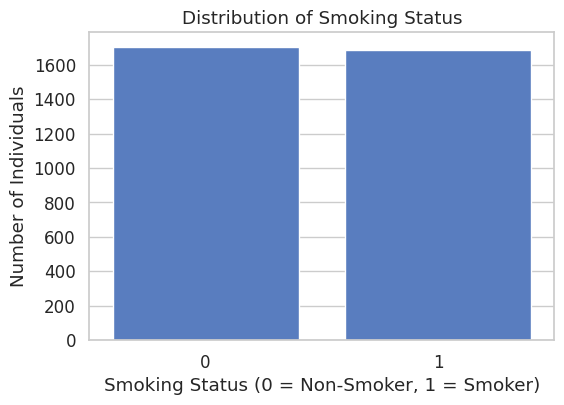

In [17]:
# Chart - 4 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 4
# Visualizing the distribution of smoking status
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on smoking status
sns.countplot(
    x='is_smoking',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Smoking Status')

# labeling the x-axis to represent smoking categories
plt.xlabel('Smoking Status (0 = Non-Smoker, 1 = Smoker)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Smoking status is a critical lifestyle factor directly linked to cardiovascular disease risk.

* A count plot is chosen because is_smoking is a binary categorical variable, and this chart clearly shows how the population is distributed between smokers and non-smokers.

* Understanding this distribution is essential before analyzing its relationship with heart disease risk.

###### 2. What is/are the insight(s) found from the chart?

From the chart, it is observed that:

* The number of smokers (1) and non-smokers (0) in the dataset is almost equal.

* There is no strong imbalance between the two groups, indicating that both smoking and non-smoking populations are well represented.

This balanced distribution suggests that the dataset captures lifestyle diversity effectively, which is beneficial for learning the impact of smoking on cardiovascular risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* A balanced representation of smokers and non-smokers enables the model to learn meaningful and unbiased patterns related to smoking behavior.

* Healthcare organizations can use insights from such models to design targeted smoking-cessation and prevention programs.

* The model’s predictions related to smoking status are likely to be more reliable due to adequate sample size for both categories.

**Potential Negative Impact:**

* While the distribution is balanced, smoking intensity (e.g., number of cigarettes per day) varies across individuals and is not captured by this chart.

* Relying solely on smoking status without considering smoking intensity could oversimplify risk estimation if not complemented by other variables.


**Conclusion :**

* The smoking status distribution is well balanced, strengthening the dataset’s ability to model smoking-related cardiovascular risk.

* However, deeper insights will emerge when smoking intensity and its interaction with other clinical variables are explored.

##### Chart - 5 Distribution of education levels

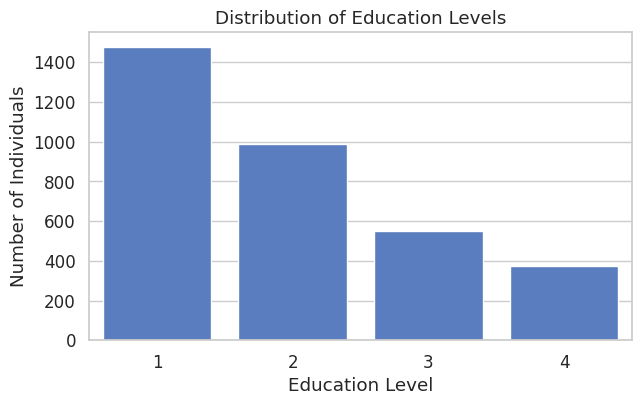

In [18]:
# Chart - 5 visualization code


# ============================================================
# 📊 Univariate Analysis – Chart 5
# Visualizing the distribution of education levels
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the count of individuals for each education level
sns.countplot(
    x='education',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Education Levels')

# labeling the x-axis to represent education categories
plt.xlabel('Education Level')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Education level is an ordinal categorical variable that often acts as a proxy for socioeconomic status, health awareness, and access to healthcare.

* A count plot is chosen because it clearly displays how individuals are distributed across discrete education categories, allowing us to understand whether certain education levels dominate the dataset and whether the variable is suitably represented for further analysis.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart, the following insights are evident:

* **Education level 1** has the highest number of individuals in the dataset.

* The count of individuals **decreases progressively** as education level increases from 1 to 4.

* **Education level 4** has the smallest representation, indicating fewer individuals with the highest education level.

* The distribution is **skewed toward lower education levels**, suggesting that a large portion of the dataset belongs to comparatively lower socioeconomic or educational groups.

This indicates that education is not uniformly distributed across the population and shows a clear ordinal trend.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Understanding the dominance of lower education levels helps healthcare providers and policymakers design targeted awareness and prevention programs for populations that may have limited health literacy.

* The model can learn education-related risk patterns more effectively for the most represented groups, improving prediction reliability for a large segment of the population.

* Education can be used as an important feature to identify vulnerable groups that may benefit from early cardiovascular screening.


**Potential Negative Impact:**

* The relatively low representation of higher education levels (especially level 4) may limit the model’s ability to learn strong patterns for this group.

* Predictions for individuals in underrepresented education categories may be less stable, which could reduce generalizability if the model is applied to populations with different educational distributions.

**Conclusion :**

* The education variable shows a clear skew toward lower education levels, highlighting potential socioeconomic disparities in the dataset.

* This insight is valuable for both predictive modeling and designing targeted public health interventions, though care must be taken when interpreting results for underrepresented education groups.

##### Chart - 6 Distribution of systolic blood pressure

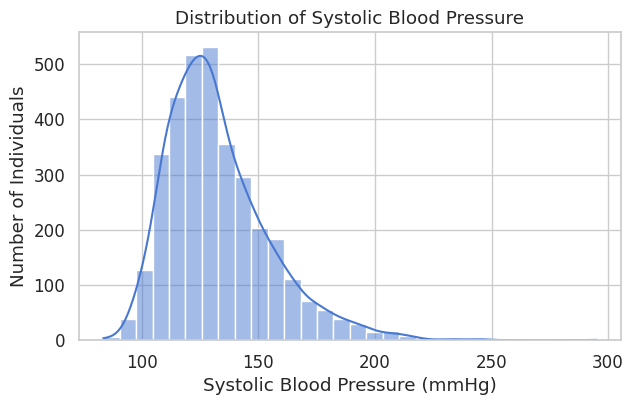

In [19]:
# Chart - 6 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 6
# Visualizing the distribution of systolic blood pressure
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of systolic blood pressure using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='sysBP',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Systolic Blood Pressure')

# labeling the x-axis to represent systolic blood pressure values
plt.xlabel('Systolic Blood Pressure (mmHg)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Systolic blood pressure (sysBP) is a critical clinical indicator for cardiovascular health and one of the strongest predictors of heart disease.

* A histogram with KDE is chosen because it effectively shows:

  * The distribution and spread of systolic blood pressure values

  * The central tendency and skewness

  * The presence of extreme or outlier values

* This visualization helps in understanding whether the population largely falls within normal, elevated, or hypertensive ranges.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart, the following insights are evident:

* Most individuals have systolic blood pressure values concentrated roughly between 110 mmHg and 150 mmHg.

* The distribution shows a right-skewed pattern, indicating the presence of individuals with higher systolic blood pressure.

* A long tail extending toward higher values (above ~180 mmHg) suggests the presence of severely hypertensive individuals.

* Very few individuals fall at extremely low systolic blood pressure levels.

This indicates that while the majority of the population lies in a moderate range, a significant subset exhibits elevated or high systolic blood pressure.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifying a right-skewed distribution with high systolic blood pressure values helps healthcare providers flag high-risk individuals for early intervention.

* Models trained on this data can learn meaningful patterns associated with hypertension-related cardiovascular risk.

* Public health programs can prioritize blood pressure screening and management initiatives for populations showing elevated systolic values.


**Potential Negative Impact:**

* The presence of extreme high values may introduce outliers that could disproportionately influence certain machine learning algorithms.

* If not handled carefully during preprocessing or modeling, these extreme values may lead to biased predictions or reduced model stability.


**Conclusion :**

* The systolic blood pressure distribution highlights a population with a wide range of blood pressure levels, including a notable right-skew with high-risk individuals.

* This reinforces the importance of blood pressure as a key predictive feature while also signaling the need for careful handling of extreme values during modeling.

##### Chart - 7 Distribution of diastolic blood pressure

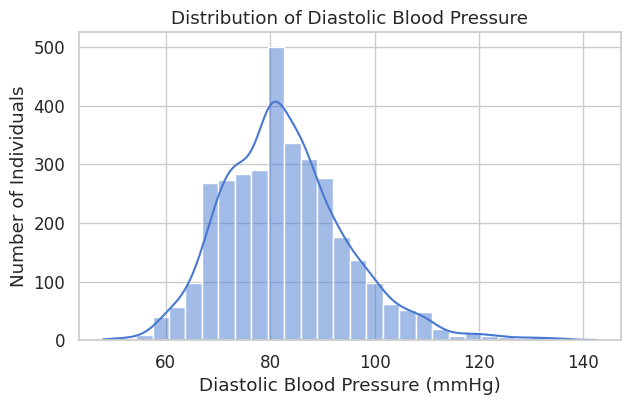

In [20]:
# Chart - 7 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 7
# Visualizing the distribution of diastolic blood pressure
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of diastolic blood pressure using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='diaBP',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Diastolic Blood Pressure')

# labeling the x-axis to represent diastolic blood pressure values
plt.xlabel('Diastolic Blood Pressure (mmHg)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Diastolic blood pressure (diaBP) is a critical physiological measure used to diagnose hypertension and assess cardiovascular health.

* A histogram with KDE is selected because it helps visualize:

  * The spread and central tendency of diastolic blood pressure values

  * The overall shape of the distribution


* The presence of skewness or extreme values
This chart is essential to understand whether the population largely falls within normal, elevated, or hypertensive diastolic pressure ranges.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution in the chart:

* Most individuals have diastolic blood pressure values concentrated roughly between 70 mmHg and 90 mmHg.

* The peak of the distribution appears around 75–80 mmHg, indicating the most common diastolic pressure range.

* The distribution shows a slight right skew, with a tail extending toward higher values above 100 mmHg.

* A small number of individuals exhibit very high diastolic blood pressure (above ~110 mmHg), indicating potential hypertension cases.

* Very low diastolic blood pressure values are relatively rare.


This suggests that while the majority of the population lies within or near the normal diastolic range, a subset of individuals is at elevated cardiovascular risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifying the concentration of individuals with normal-to-elevated diastolic blood pressure allows healthcare providers to focus preventive care on borderline cases before they progress to severe hypertension.

* Predictive models can leverage this variable effectively, as it shows meaningful variation across individuals.

* Public health initiatives can prioritize blood pressure monitoring programs based on these insights.


**Potential Negative Impact:**

* The presence of extreme high diastolic values may act as outliers and could disproportionately influence certain machine learning models if not handled properly.

* If such extreme values are ignored or improperly treated, model predictions may become unstable or biased.


**Conclusion :**

* The diastolic blood pressure distribution shows that most individuals fall within a clinically reasonable range, while a smaller subset exhibits elevated values associated with higher cardiovascular risk.

* This reinforces the importance of diaBP as a strong predictive feature and highlights the need for careful handling of extreme values during modeling.

##### Chart - 8 Distribution of body mass index (BMI)

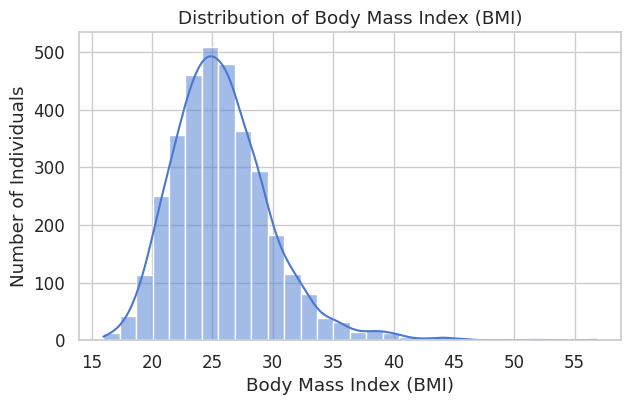

In [21]:
# Chart - 8 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 8
# Visualizing the distribution of body mass index (BMI)
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of BMI using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='BMI',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Body Mass Index (BMI)')

# labeling the x-axis to represent BMI values
plt.xlabel('Body Mass Index (BMI)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Body Mass Index (BMI) is a widely used clinical indicator for assessing obesity and overweight status, both of which are strongly associated with cardiovascular risk.

* A histogram with KDE is chosen because it clearly shows:

  * The distribution and spread of BMI values

  * The central tendency and skewness

  * The presence of extreme or outlier BMI values

* This visualization helps understand whether the population largely falls into normal, overweight, or obese BMI categories.

###### 2. What is/are the insight(s) found from the chart?

From the observed BMI distribution:

* Most individuals have BMI values concentrated roughly between 22 and 30.

* The peak of the distribution appears around 24–26, indicating that a large portion of individuals fall near the upper end of the normal or early overweight range.

* The distribution is right-skewed, with a long tail extending toward higher BMI values.

* A smaller number of individuals have very high BMI values (above ~35), indicating obesity.

* Very low BMI values are rare, suggesting underweight individuals are minimally represented.

This indicates that overweight and obesity are prevalent in the dataset, which is clinically relevant for cardiovascular risk analysis.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The presence of a large overweight and obese population allows the model to learn strong BMI-related cardiovascular risk patterns.

* Healthcare providers can use such insights to design lifestyle intervention programs focusing on weight management.

* Public health strategies can prioritize obesity prevention as a key factor in reducing long-term heart disease risk.

**Potential Negative Impact:**

* Extreme BMI values may act as outliers and could influence model performance if not handled carefully during modeling.

* If BMI is used without considering related factors such as age, blood pressure, and glucose, it may oversimplify risk estimation.

**Conclusion :**

The BMI distribution highlights a population with a significant proportion of individuals in the overweight and obese ranges, reinforcing BMI as a critical feature for cardiovascular risk prediction while also signaling the need for careful handling of extreme values.

##### Chart - 9 Distribution of resting heart rate

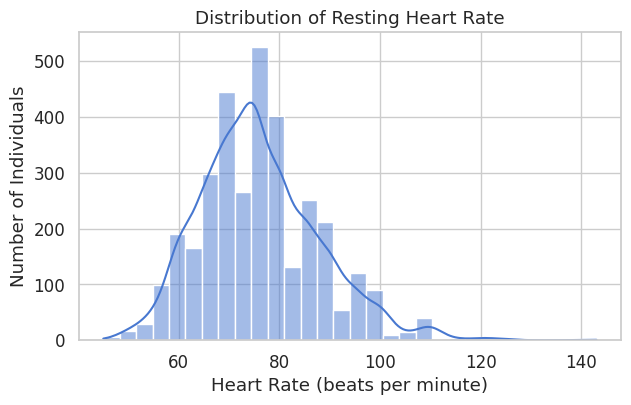

In [22]:
# Chart - 9 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 9
# Visualizing the distribution of resting heart rate
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of heart rate using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='heartRate',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Resting Heart Rate')

# labeling the x-axis to represent heart rate values
plt.xlabel('Heart Rate (beats per minute)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Resting heart rate is an important physiological indicator of cardiovascular health and overall fitness.

* A histogram with KDE is chosen because it helps visualize:

  * The distribution and spread of resting heart rate values

  * The most common heart rate range in the population

* The presence of skewness or extreme heart rate values
This chart is useful to understand whether the dataset primarily consists of individuals with normal, elevated, or abnormal resting heart rates.

###### 2. What is/are the insight(s) found from the chart?

Based on the observed distribution:

* Most individuals have resting heart rates concentrated roughly between 60 and 85 beats per minute (bpm).

* The peak of the distribution appears around 70–75 bpm, which lies within the clinically normal resting heart rate range.

* The distribution shows a slight right skew, with a tail extending toward higher heart rate values.

* A small number of individuals exhibit very high resting heart rates (above ~100 bpm), which may indicate potential cardiovascular stress or underlying health conditions.

* Very low heart rate values are rare, suggesting limited representation of individuals with bradycardia.

This indicates that while the majority of individuals fall within a normal resting heart rate range, a subset shows elevated heart rates that could be clinically significant.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The presence of a well-distributed normal heart rate range allows predictive models to learn meaningful baseline patterns.

* Elevated heart rate values can help identify individuals who may require further clinical evaluation or lifestyle intervention.

* Healthcare systems can leverage such insights for early screening and preventive cardiovascular care.


**Potential Negative Impact:**

* Extreme heart rate values may act as outliers and could influence model performance if not handled carefully.

* If resting heart rate is analyzed in isolation without considering physical activity levels or medication usage, it may lead to incomplete risk interpretation.


**Conclusion :**

* The resting heart rate distribution suggests a population largely within the normal physiological range, with a smaller subset exhibiting elevated values associated with increased cardiovascular risk.

* This reinforces heart rate as a meaningful feature while highlighting the importance of contextual interpretation during modeling.

##### Chart - 10 Distribution of total cholesterol

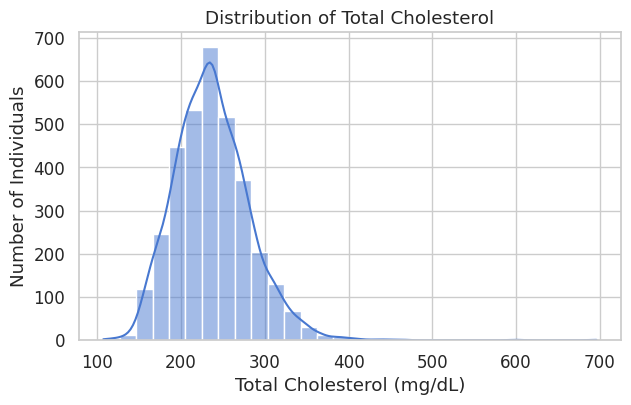

In [23]:
# Chart - 10 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 10
# Visualizing the distribution of total cholesterol
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of total cholesterol using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='totChol',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Total Cholesterol')

# labeling the x-axis to represent total cholesterol values
plt.xlabel('Total Cholesterol (mg/dL)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Total cholesterol is a key biochemical indicator directly associated with cardiovascular disease risk.

* A histogram with KDE is chosen because it helps visualize:

  * The distribution and spread of cholesterol levels

  * The central tendency and skewness of the data

  * The presence of extreme cholesterol values

* This visualization allows us to understand whether most individuals fall within normal, borderline, or high cholesterol ranges.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution in the chart:

* Most individuals have total cholesterol values concentrated roughly between 180 mg/dL and 280 mg/dL.

* The peak of the distribution appears around 220–240 mg/dL, which lies close to the clinically borderline-to-high cholesterol range.

* The distribution is right-skewed, with a long tail extending toward higher cholesterol values.

* A small number of individuals show very high cholesterol levels (above ~350 mg/dL), indicating elevated cardiovascular risk.

* Extremely low cholesterol values are rare in the dataset.


This suggests that a significant portion of the population has borderline or elevated cholesterol levels.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The presence of a wide range of cholesterol values allows the predictive model to learn meaningful risk patterns related to lipid levels.

* Healthcare providers can use such insights to prioritize cholesterol screening and lipid-management programs.

* Public health initiatives can target populations with elevated cholesterol to reduce long-term cardiovascular disease burden.


**Potential Negative Impact:**

* Extreme cholesterol values may act as outliers and could influence model training if not handled carefully.

* If cholesterol is analyzed without considering other related factors such as age, blood pressure, and diabetes status, risk interpretation may be incomplete.


**Conclusion :**

* The total cholesterol distribution shows a right-skewed pattern with a substantial number of individuals in the borderline-to-high cholesterol range.

* This reinforces total cholesterol as a critical feature for cardiovascular risk prediction while highlighting the need for careful handling of extreme values during modeling.

##### Chart - 11 Distribution of blood glucose levels

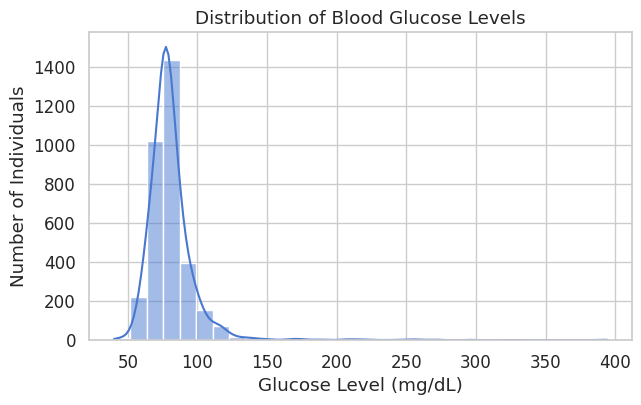

In [24]:
# Chart - 11 visualization code


# ============================================================
# 📊 Univariate Analysis – Chart 11
# Visualizing the distribution of blood glucose levels
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of glucose levels using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='glucose',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Blood Glucose Levels')

# labeling the x-axis to represent glucose values
plt.xlabel('Glucose Level (mg/dL)')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Blood glucose level is a key metabolic indicator closely linked to diabetes, which is a major risk factor for cardiovascular disease.

* A histogram with KDE is chosen because it allows clear visualization of:

  * The distribution and concentration of glucose values

  * The central tendency and spread

  * The presence of skewness and extreme glucose values

* This chart helps in understanding whether the population largely falls within normal, prediabetic, or diabetic glucose ranges.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution:

* Most individuals have glucose levels concentrated roughly between 70 mg/dL and 100 mg/dL, which corresponds to the normal fasting glucose range.

* The peak of the distribution appears around 80–90 mg/dL, indicating that a large portion of individuals have normal glucose levels.

* The distribution is strongly right-skewed, with a long tail extending toward higher glucose values.

* A small subset of individuals shows very high glucose levels (above ~140 mg/dL), suggesting possible diabetic or uncontrolled glucose conditions.

* Extremely low glucose values are rare in the dataset.

This indicates that while most individuals maintain normal glucose levels, there is a clinically important minority at elevated metabolic risk.


###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifying individuals with elevated glucose levels enables early detection of diabetes-related cardiovascular risk.

* Predictive models can leverage glucose as a strong indicator to improve risk stratification accuracy.

* Healthcare systems can design targeted screening and intervention programs for populations with abnormal glucose levels.

**Potential Negative Impact:**

* The presence of extreme glucose values may act as outliers and could influence model performance if not addressed carefully.

* If glucose measurements are used without context (e.g., fasting vs non-fasting), risk interpretation may be less precise.


**Conclusion :**

* The glucose distribution reveals a largely healthy population with normal glucose levels, alongside a smaller high-risk group exhibiting elevated values.

* This reinforces glucose as a crucial feature for cardiovascular risk prediction while highlighting the need for careful handling of extreme values during modeling.




##### Chart - 12 Distribution of blood pressure medication status

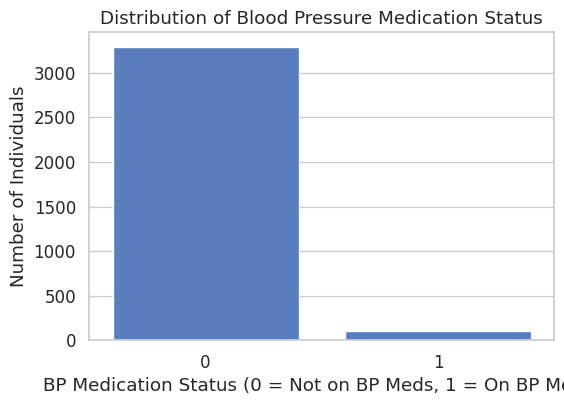

In [25]:
# Chart - 12 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 12
# Visualizing the distribution of blood pressure medication status
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on BP medication status
sns.countplot(
    x='BPMeds',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Blood Pressure Medication Status')

# labeling the x-axis to represent BP medication categories
plt.xlabel('BP Medication Status (0 = Not on BP Meds, 1 = On BP Meds)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* BPMeds indicates whether an individual is taking blood pressure medication, which is an important clinical factor reflecting existing hypertension management.

* A count plot is chosen because BPMeds is a binary categorical variable, and this chart clearly shows the proportion of individuals on medication versus those not receiving treatment.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart:

* A large majority of individuals are not on blood pressure medication (BPMeds = 0).

* Only a very small proportion of individuals are on BP medication (BPMeds = 1).

* This indicates a highly imbalanced distribution for this variable.

The imbalance suggests that most individuals in the dataset are either not diagnosed with hypertension or are not undergoing pharmacological treatment, while only a limited subset is actively managing blood pressure through medication.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Identifying a small treated population helps healthcare providers recognize gaps in hypertension treatment coverage.

* The model can potentially learn the impact of untreated versus treated hypertension on cardiovascular risk.

* These insights can guide policy decisions and public health initiatives focused on improving diagnosis and medication adherence.

**Potential Negative Impact:**

* The extreme class imbalance may reduce the predictive power of this variable during model training.

* Models may struggle to learn meaningful patterns related to BP medication usage due to limited representation.

* If imbalance is not handled carefully, predictions for medicated individuals may be less reliable.


**Conclusion :**

* The blood pressure medication status shows a strong imbalance, with most individuals not on treatment.

* While this highlights potential public health gaps, it also signals the need for careful modeling strategies to ensure reliable predictions for the underrepresented medicated group.

##### Chart - 13 Distribution of cigarettes smoked per day

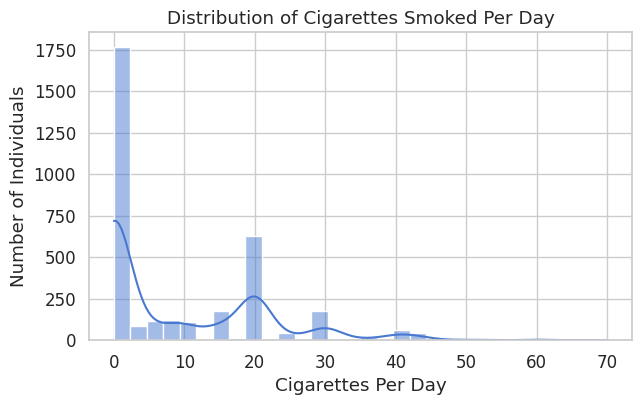

In [26]:
# Chart - 13 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 13
# Visualizing the distribution of cigarettes smoked per day
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting the distribution of cigarettes per day using histogram with KDE
sns.histplot(
    data=df_wrangle,
    x='cigsPerDay',
    bins=30,
    kde=True
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Cigarettes Smoked Per Day')

# labeling the x-axis to represent number of cigarettes smoked per day
plt.xlabel('Cigarettes Per Day')

# labeling the y-axis to represent the frequency of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* cigsPerDay represents smoking intensity, which provides more granular information than smoking status alone.

* A histogram with KDE is chosen because it helps visualize:

  * How many cigarettes individuals smoke per day

  * The concentration of light, moderate, and heavy smokers

  * The presence of skewness and extreme smoking behavior

* This chart is important for understanding lifestyle-related cardiovascular risk beyond a simple smoker/non-smoker classification.

###### 2. What is/are the insight(s) found from the chart?

From the observed distribution:

* A very large spike at 0 cigarettes per day is visible, indicating a substantial number of non-smokers in the dataset.

* Among smokers, most individuals smoke between 10 and 25 cigarettes per day, suggesting a concentration of moderate smokers.

* The distribution is highly right-skewed, with a long tail extending toward higher cigarette consumption.

* A small number of individuals smoke more than 30 cigarettes per day, representing heavy smokers.
Extremely high values (above ~50 cigarettes per day) are rare.

This shows a mixed population consisting largely of non-smokers, followed by moderate smokers, with relatively few heavy smokers.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Differentiating between non-smokers, moderate smokers, and heavy smokers allows the model to capture nuanced smoking-related cardiovascular risk.

* Healthcare providers can use this information to design targeted smoking-cessation programs based on smoking intensity.

* Public health strategies can prioritize intervention for heavy smokers, who represent a high-risk subgroup.


**Potential Negative Impact:**

* The strong skew and concentration at zero may dominate the distribution, potentially reducing the influence of smoking intensity for smokers if not handled carefully during modeling.

* Extreme smoking values may act as outliers and could negatively impact certain machine learning algorithms.


**Conclusion :**

* The distribution of cigarettes smoked per day reveals a population dominated by non-smokers, followed by moderate smokers, with a small subset of heavy smokers.

* This reinforces smoking intensity as an important yet unevenly distributed risk factor that requires careful modeling consideration.

##### Chart - 14 Distribution of Prevalent Hypertension

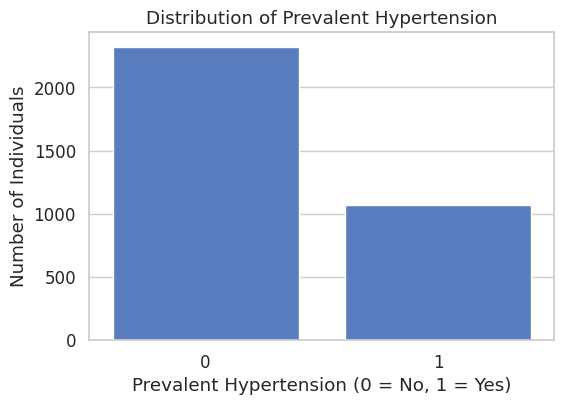

In [27]:
# Chart - 14 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 14
# Visualizing the distribution of prevalent hypertension
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on hypertension status
sns.countplot(
    x='prevalentHyp',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Prevalent Hypertension')

# labeling the x-axis to represent hypertension categories
plt.xlabel('Prevalent Hypertension (0 = No, 1 = Yes)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* prevalentHyp indicates whether an individual already has a history of hypertension, which is one of the strongest and most established risk factors for cardiovascular disease.

* A count plot is chosen because this variable is binary, and the chart clearly shows how the population is split between individuals with and without pre-existing hypertension.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart:

* A larger proportion of individuals do not have prevalent hypertension (prevalentHyp = 0).

* A substantial minority of individuals have prevalent hypertension (prevalentHyp = 1).

* While the dataset is skewed toward non-hypertensive individuals, the hypertensive group is significant in size, not negligible.

* This indicates that the dataset includes a meaningful number of individuals who already have hypertension, which is valuable for learning cardiovascular risk patterns.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The presence of a sizable hypertensive population enables predictive models to learn how existing hypertension contributes to future coronary heart disease risk.

* Healthcare providers can use such insights to prioritize follow-ups and preventive interventions for hypertensive patients.

* Public health programs can focus on hypertension management as a key strategy for reducing long-term cardiovascular events.


**Potential Negative Impact:**

* The imbalance between hypertensive and non-hypertensive individuals may slightly bias the model toward the majority group if not addressed properly.

* If the hypertensive group is not sufficiently emphasized during modeling, the model may underestimate risk for individuals with existing hypertension.


**Conclusion :**

* The prevalent hypertension distribution shows that while most individuals do not have hypertension, a considerable portion already does.

* This reinforces hypertension as a critical predictor for cardiovascular risk and highlights the need for careful modeling to ensure reliable predictions for hypertensive individuals.

##### Chart - 15 Distribution of Diabetes Status

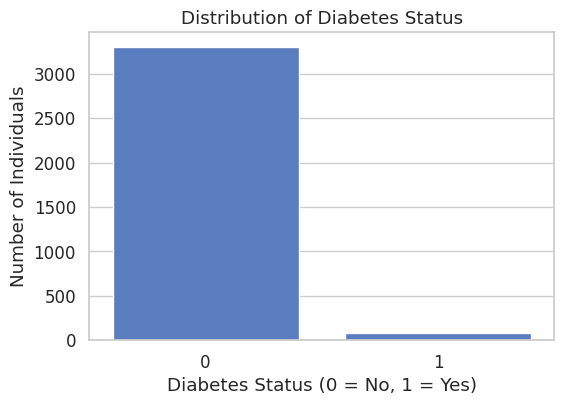

In [28]:
# Chart - 15 visualization code


# ============================================================
# 📊 Univariate Analysis – Chart 15
# Visualizing the distribution of diabetes status
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on diabetes status
sns.countplot(
    x='diabetes',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Diabetes Status')

# labeling the x-axis to represent diabetes categories
plt.xlabel('Diabetes Status (0 = No, 1 = Yes)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* diabetes is a critical metabolic condition and one of the strongest established risk factors for cardiovascular disease.

* A count plot is chosen because diabetes status is a binary categorical variable, and this chart clearly shows how the population is distributed between diabetic and non-diabetic individuals.

* Understanding this distribution is essential before analyzing its relationship with cardiovascular outcomes.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart:

* An overwhelming majority of individuals do not have diabetes (diabetes = 0).

* Only a very small fraction of individuals are diabetic (diabetes = 1).

* This indicates a highly imbalanced distribution for the diabetes variable.

The dataset therefore contains very limited representation of diabetic individuals compared to non-diabetic individuals.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Even though the diabetic population is small, its presence is clinically important, as diabetes significantly elevates cardiovascular risk.

* The model can still learn strong risk signals from diabetic cases, especially when combined with glucose, BMI, and blood pressure variables.

* Healthcare decision-makers can use such insights to prioritize cardiovascular screening among diabetic individuals.

**Potential Negative Impact:**

* The extreme class imbalance may limit the model’s ability to generalize diabetes-related risk patterns.

* If not handled carefully, the model may underperform for diabetic individuals due to their low representation.

* Specialized techniques (class weighting or careful evaluation metrics) may be required during modeling to avoid bias.


**Conclusion :**

* The diabetes distribution shows that most individuals in the dataset are non-diabetic, with only a small high-risk diabetic subgroup.

* While this reflects real-world population trends, it highlights the need for careful modeling strategies to ensure reliable cardiovascular risk prediction for diabetic individuals.

##### Chart - 16 Distribution of Prevalent Stroke

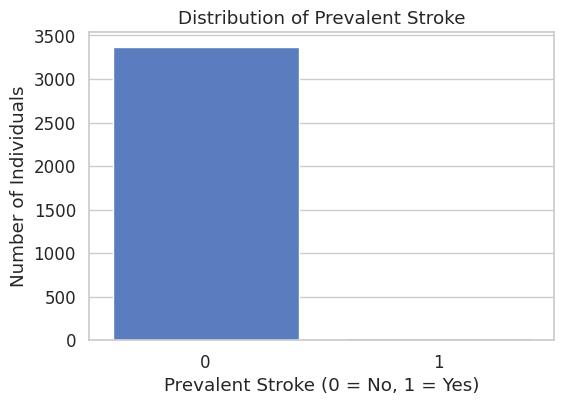

In [29]:
# Chart - 16 visualization code

# ============================================================
# 📊 Univariate Analysis – Chart 16
# Visualizing the distribution of prevalent stroke history
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(6, 4))

# plotting the count of individuals based on stroke history
sns.countplot(
    x='prevalentStroke',
    data=df_wrangle
)

# setting the title to describe the distribution being visualized
plt.title('Distribution of Prevalent Stroke')

# labeling the x-axis to represent stroke history categories
plt.xlabel('Prevalent Stroke (0 = No, 1 = Yes)')

# labeling the y-axis to represent the number of individuals
plt.ylabel('Number of Individuals')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* prevalentStroke indicates whether an individual has a history of stroke, which is a serious cardiovascular event and a strong clinical risk marker for future heart disease.

* A count plot is chosen because this variable is binary, and the chart clearly shows how frequently prior stroke cases appear in the dataset compared to non-stroke cases.

* Understanding this distribution is important to assess how well prior stroke history is represented in the data.

###### 2. What is/are the insight(s) found from the chart?

From the observed chart:

* Almost all individuals have no history of stroke (prevalentStroke = 0).

* The number of individuals with a prior stroke (prevalentStroke = 1) is extremely small or nearly absent.

* This shows an extreme class imbalance for the stroke history variable.

The dataset therefore contains very limited representation of individuals with prior stroke, making this a rare event feature.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* Even though prior stroke cases are rare, their presence is clinically significant, as stroke history greatly increases cardiovascular risk.

* The model can still use this variable as a high-risk signal when it occurs, helping identify individuals who require urgent or specialized care.

* Healthcare systems can use this insight to emphasize post-stroke monitoring and preventive strategies.

**Potential Negative Impact:**

* The extreme imbalance means the model may struggle to learn meaningful patterns related to prior stroke history.

* Predictions involving this variable may be unreliable due to the very small sample size.

* Without careful modeling strategies, the feature may contribute little predictive power or introduce instability.


**Conclusion :**

* The prevalent stroke distribution highlights that prior stroke is a rare event in the dataset.

* While this reflects real-world population trends, it also signals the need for careful handling during modeling to ensure that this high-risk but low-frequency feature is interpreted correctly.

#### Bivariate Analysis

##### Chart - 17 Relationship between age and 10-year CHD risk

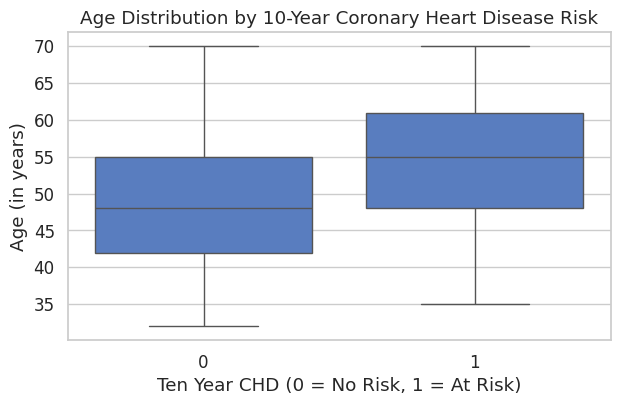

In [89]:
# Chart - 17 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 1
# Visualizing the relationship between age and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare age distribution across CHD classes
sns.boxplot(
    x='TenYearCHD',
    y='age',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Age Distribution by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent age in years
plt.ylabel('Age (in years)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Age is a continuous numerical variable, while TenYearCHD is a binary target variable.

* A box plot is chosen because it effectively compares the distribution, median, spread, and variability of age across the two target classes.

* This makes it ideal for identifying whether age differs meaningfully between individuals who are at risk and those who are not.

###### 2. What is/are the insight(s) found from the chart?

* Individuals at risk of coronary heart disease (TenYearCHD = 1) have a higher median age compared to those not at risk (TenYearCHD = 0).

* The interquartile range (IQR) for the at-risk group is shifted toward older ages, indicating that CHD risk increases with age.

* Younger individuals are more concentrated in the non-risk group, while older individuals are more prevalent in the risk group.

* There is some overlap between the two groups, but the overall age distribution for the at-risk group is clearly higher.

This confirms a strong positive association between age and 10-year coronary heart disease risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight allows healthcare providers to prioritize age-based screening and preventive interventions.

* Predictive models can effectively use age as a strong feature to improve cardiovascular risk prediction accuracy.

* Public health policies can focus on early detection strategies for middle-aged and elderly populations to reduce long-term healthcare costs.


**Potential Negative Impact:**


* Since age is a non-modifiable factor, relying too heavily on age alone may overlook younger individuals with high risk due to lifestyle or genetic factors.

* If not combined with other clinical features, age-based predictions could lead to under-screening of younger at-risk individuals.


**Conclusion :**

* The box plot clearly demonstrates that age is a significant factor associated with increased 10-year coronary heart disease risk.

* While age alone should not drive decision-making, it plays a critical role when combined with other lifestyle and clinical variables.

##### Chart - 18 Relationship between systolic BP and 10-year CHD risk

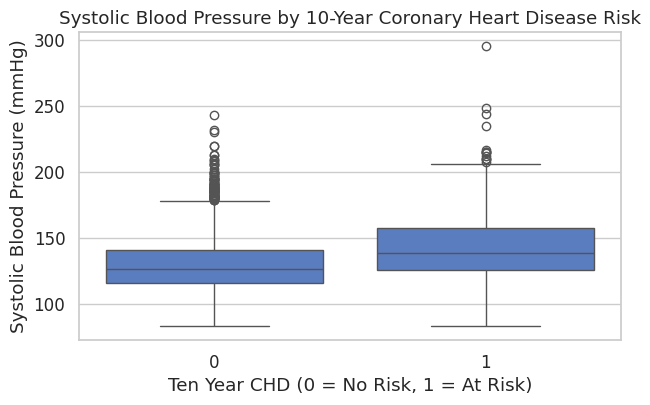

In [90]:
# Chart - 18 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 2
# Visualizing the relationship between systolic BP and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare systolic BP across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='sysBP',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Systolic Blood Pressure by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent systolic blood pressure values
plt.ylabel('Systolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Systolic blood pressure (sysBP) is a continuous clinical measurement and one of the most important modifiable risk factors for cardiovascular disease.

* A box plot is chosen to compare the distribution, median, spread, and presence of outliers of systolic blood pressure across the two CHD risk categories.

* This chart helps assess whether elevated systolic blood pressure is associated with higher 10-year CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a higher median systolic blood pressure compared to those in the non-risk group.

* The overall distribution of systolic blood pressure for at-risk individuals is shifted toward higher values.

* The at-risk group exhibits greater variability and more extreme high-value outliers, indicating cases of severe hypertension.

* Although there is overlap between the two groups, higher systolic blood pressure levels are more common among individuals at risk.

* This suggests a clear positive association between elevated systolic blood pressure and 10-year coronary heart disease risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* These insights reinforce the importance of blood pressure control in preventing cardiovascular disease.

* Predictive models can leverage systolic blood pressure as a strong feature to improve CHD risk prediction.

* Healthcare providers can use this information to prioritize early intervention and monitoring for individuals with elevated systolic BP.


**Potential Negative Impact:**

* Presence of extreme outliers may skew model training if not handled properly.

* Over-reliance on systolic BP alone may overlook individuals with normal BP but other significant risk factors.

* Poor data handling of outliers could lead to unstable predictions.


**Conclusion :**

* The chart clearly indicates that higher systolic blood pressure is associated with increased 10-year coronary heart disease risk.

* While systolic BP is a powerful predictor, it should be interpreted alongside other clinical and lifestyle variables for balanced decision-making.

##### Chart - 19 Relationship between diastolic BP and 10-year CHD risk

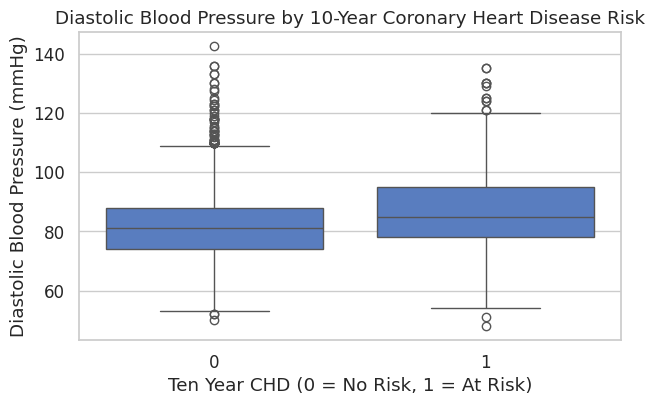

In [91]:
# Chart - 19 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 3
# Visualizing the relationship between diastolic BP and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare diastolic BP across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='diaBP',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Diastolic Blood Pressure by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent diastolic blood pressure values
plt.ylabel('Diastolic Blood Pressure (mmHg)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Diastolic blood pressure (diaBP) is a continuous cardiovascular measurement and an important indicator of vascular resistance and heart workload.

* A box plot is selected because it allows direct comparison of the distribution, median, variability, and outliers of diastolic blood pressure between individuals who are at risk and not at risk of coronary heart disease.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a slightly higher median diastolic blood pressure compared to the non-risk group.

* The distribution for the at-risk group is shifted marginally upward, indicating higher diastolic BP levels.

* Both groups exhibit several high-value outliers, but the at-risk group shows more concentration toward elevated values.

* There is notable overlap between the two groups, suggesting that diastolic BP alone is not a strong separator but still contributes to risk.

* This indicates a moderate positive association between elevated diastolic blood pressure and 10-year CHD risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* These insights highlight the importance of monitoring diastolic blood pressure alongside systolic pressure in cardiovascular risk assessment.

* Predictive models can benefit from including diastolic BP as a complementary feature to improve overall prediction robustness.

* Healthcare providers can design balanced hypertension management strategies focusing on both systolic and diastolic measures.


**Potential Negative Impact:**

* The overlapping distributions indicate limited standalone predictive power.

* Overemphasizing diastolic BP without considering other variables may lead to inaccurate risk stratification.

* Presence of outliers may require preprocessing to avoid model instability.

**Conclusion :**

* The chart shows that diastolic blood pressure is moderately higher among individuals at risk of coronary heart disease.

* While it is not a dominant predictor on its own, it plays a meaningful supporting role when combined with other cardiovascular indicators.

##### Chart - 20 Body Mass Index by 10-Year Coronary Heart Disease Risk

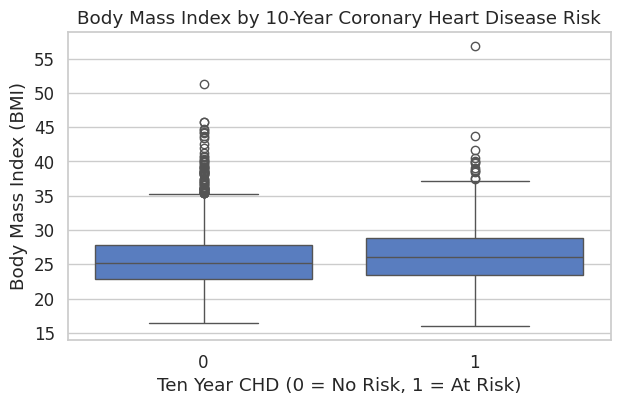

In [92]:
# Chart - 20 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 4
# Visualizing the relationship between BMI and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare BMI distribution across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='BMI',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Body Mass Index by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent BMI values
plt.ylabel('Body Mass Index (BMI)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Body Mass Index (BMI) is a continuous numerical variable and a widely used indicator of overweight and obesity, both of which are known contributors to cardiovascular disease.

* A box plot is selected to compare the distribution, median, spread, and presence of outliers of BMI across individuals with and without 10-year coronary heart disease risk.

* This visualization helps assess whether higher body mass is associated with increased CHD risk.


###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a slightly higher median BMI compared to those in the non-risk group.

* The BMI distribution for the at-risk group is shifted marginally upward, indicating a tendency toward higher body mass.

* Both groups exhibit several high-BMI outliers, suggesting the presence of obese individuals in both risk categories.

* There is substantial overlap between the two distributions, indicating that BMI alone does not sharply separate the risk groups.

* Overall, BMI shows a weak to moderate positive association with 10-year coronary heart disease risk.


###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The insights reinforce the role of weight management in cardiovascular disease prevention.

* Including BMI in predictive models can help improve risk stratification when combined with blood pressure, age, and metabolic factors.

* Healthcare organizations can design lifestyle intervention programs targeting overweight and obese populations to reduce long-term CHD risk.

**Potential Negative Impact:**

* The strong overlap between BMI distributions may reduce its standalone predictive value.

* Sole reliance on BMI could overlook individuals with normal BMI but high cardiovascular risk due to other factors.

* Outliers may require careful preprocessing to prevent skewed model behavior.

**Conclusion :**

* The chart indicates that higher BMI is modestly associated with increased 10-year coronary heart disease risk.

* While BMI alone is not a decisive predictor, it contributes meaningful context when used alongside other clinical and lifestyle variables.



##### Chart - 21 Blood Glucose Levels by 10-Year Coronary Heart Disease Risk

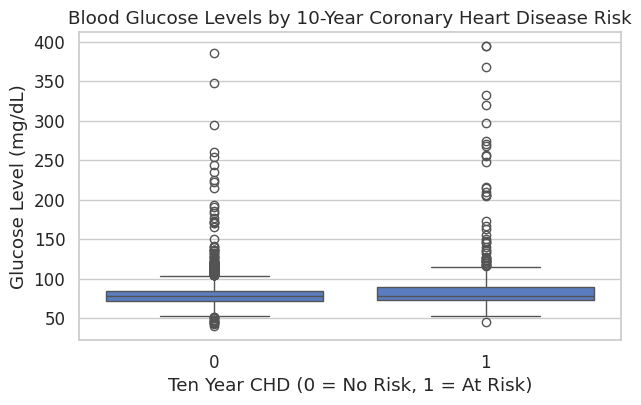

In [93]:
# Chart - 21 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 5
# Visualizing the relationship between glucose level and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare glucose levels across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='glucose',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Blood Glucose Levels by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent glucose levels
plt.ylabel('Glucose Level (mg/dL)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Blood glucose level is a continuous metabolic variable and a strong indicator of diabetes and insulin resistance, both of which are closely linked to cardiovascular disease.

* A box plot is chosen to compare the distribution, median, spread, and outliers of glucose levels between individuals who are at risk and not at risk of developing coronary heart disease within 10 years.

* This visualization helps evaluate whether elevated glucose levels are associated with higher CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) have a slightly higher median glucose level compared to the non-risk group.

* The glucose distribution for the at-risk group is shifted marginally upward, indicating higher blood glucose levels among those at risk.

* The at-risk group shows more extreme high-value outliers, representing individuals with very high glucose levels.

* There is considerable overlap between the two groups, suggesting glucose alone does not sharply distinguish CHD risk but contributes meaningful information.

* Overall, glucose shows a moderate positive association with 10-year coronary heart disease risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* These findings emphasize the importance of glycemic control in reducing cardiovascular risk.

* Predictive models can benefit from including glucose as a feature, especially when combined with diabetes status, BMI, and blood pressure.

* Healthcare providers can target early interventions for individuals with elevated glucose to prevent long-term cardiovascular complications.


**Potential Negative Impact:**

* The strong presence of outliers may affect model stability if not handled carefully.

* Overlapping distributions reduce glucose’s standalone predictive power.

* If glucose values are noisy or inconsistently measured, they may introduce variance into the model.


**Conclusion :**

* The chart indicates that higher blood glucose levels are associated with increased 10-year coronary heart disease risk, although the relationship is moderate.

* Glucose is most effective as a predictive feature when combined with other metabolic and clinical variables.

##### Chart - 22 Total Cholesterol Levels by 10-Year Coronary Heart Disease Risk

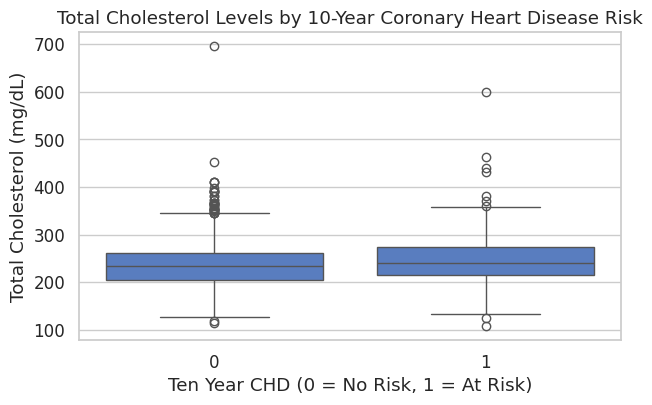

In [95]:
# Chart - 22 visualization code


# ============================================================
# 📊 Bivariate Analysis – Chart 6
# Visualizing the relationship between total cholesterol and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare total cholesterol levels across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='totChol',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Total Cholesterol Levels by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent total cholesterol values
plt.ylabel('Total Cholesterol (mg/dL)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Total cholesterol (totChol) is a continuous biochemical variable and one of the primary clinical indicators used to assess cardiovascular health.

* A box plot is chosen because it allows comparison of the distribution, median, variability, and outliers of cholesterol levels across individuals with and without 10-year coronary heart disease risk.

* This visualization helps evaluate whether elevated cholesterol levels are associated with increased CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a slightly higher median total cholesterol level compared to the non-risk group.

* The distribution for the at-risk group is shifted modestly toward higher cholesterol values.

* Both groups exhibit several high-value outliers, indicating individuals with very high cholesterol levels in both risk categories.

* There is substantial overlap between the two distributions, suggesting cholesterol alone does not clearly separate CHD risk groups.

* Overall, total cholesterol shows a weak to moderate positive association with 10-year coronary heart disease risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The insight reinforces the importance of cholesterol monitoring and lipid management in cardiovascular risk reduction.

* Including total cholesterol in predictive models can improve performance when combined with age, blood pressure, glucose, and lifestyle factors.

* Healthcare systems can use this information to promote preventive care such as dietary changes and lipid-lowering therapies.


**Potential Negative Impact:**

* The large overlap between the two groups reduces cholesterol’s standalone predictive power.

* Presence of extreme outliers may affect model training if not handled carefully.

* Over-reliance on total cholesterol without considering HDL, LDL, or other lipid markers may oversimplify risk assessment.

**Conclusion :**

* The chart indicates that higher total cholesterol levels are associated with increased 10-year coronary heart disease risk, though the relationship is moderate.

* Total cholesterol is most effective as a predictive feature when used in combination with other clinical and lifestyle variables.

##### Chart - 23 relationship between heart rate and 10-year CHD risk

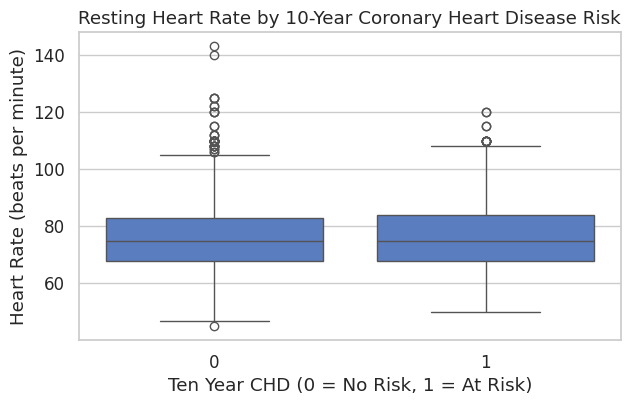

In [96]:
# Chart - 23 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 7
# Visualizing the relationship between heart rate and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare heart rate across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='heartRate',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Resting Heart Rate by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent resting heart rate values
plt.ylabel('Heart Rate (beats per minute)')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* Resting heart rate is a continuous physiological variable that reflects cardiovascular fitness and autonomic nervous system activity.

* A box plot is chosen because it allows comparison of the distribution, median, spread, and outliers of heart rate between individuals who are at risk and not at risk of developing coronary heart disease within 10 years.

* This chart helps assess whether resting heart rate differs meaningfully between CHD risk groups.

###### 2. What is/are the insight(s) found from the chart?

* The median heart rate for individuals at risk (TenYearCHD = 1) is very similar to that of individuals not at risk (TenYearCHD = 0).

* The overall distributions of heart rate for both groups overlap heavily, indicating minimal separation.

* Both groups show several high-value outliers, representing individuals with unusually elevated resting heart rates.

* The spread (IQR) is comparable across both categories, suggesting similar variability.

* This indicates that resting heart rate shows a weak or negligible direct association with 10-year coronary heart disease risk in this dataset.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* This insight prevents overemphasis on heart rate as a primary risk factor in predictive modeling.

* Heart rate can still contribute value when combined with other variables such as blood pressure, age, and glucose.

* Healthcare providers can interpret elevated heart rate as a general health indicator rather than a standalone CHD predictor.


**Potential Negative Impact:**

* Including heart rate without proper feature evaluation may add noise to the model.

* Its weak discriminatory power may slightly reduce model efficiency if not weighted appropriately.

* Overinterpreting heart rate could divert attention from stronger predictors.

**Conclusion :**

* The chart suggests that resting heart rate does not strongly differentiate individuals at risk of coronary heart disease from those not at risk.

* While it remains clinically relevant, heart rate is best used as a supporting feature rather than a dominant predictor in CHD risk models.

##### Chart - 24 Relationship between cigarettes per day and 10-year CHD risk

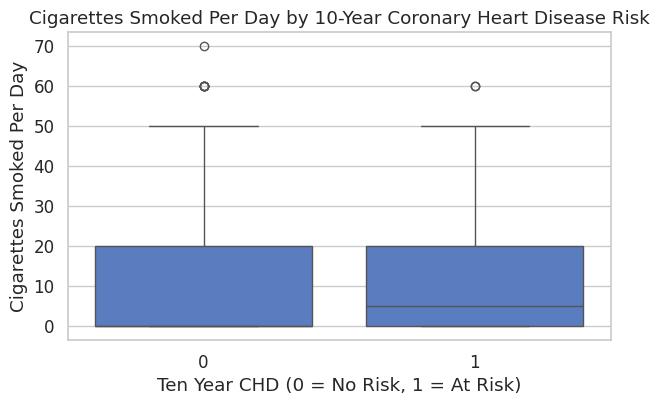

In [97]:
# Chart - 24 visualization code

# ============================================================
# 📊 Bivariate Analysis – Chart 8
# Visualizing the relationship between cigarettes per day and 10-year CHD risk
# ============================================================

# creating a new figure to define the size of the plot
plt.figure(figsize=(7, 4))

# plotting a boxplot to compare cigarettes smoked per day across CHD risk categories
sns.boxplot(
    x='TenYearCHD',
    y='cigsPerDay',
    data=df_wrangle
)

# setting the title to describe the relationship being visualized
plt.title('Cigarettes Smoked Per Day by 10-Year Coronary Heart Disease Risk')

# labeling the x-axis to represent CHD risk categories
plt.xlabel('Ten Year CHD (0 = No Risk, 1 = At Risk)')

# labeling the y-axis to represent number of cigarettes smoked per day
plt.ylabel('Cigarettes Smoked Per Day')

# displaying the final plot
plt.show()

###### 1. Why did you pick the specific chart?

* cigsPerDay is a continuous numerical variable that directly quantifies smoking intensity, which is a well-established lifestyle risk factor for coronary heart disease.

* A box plot is chosen to compare the distribution, median, spread, and outliers of daily cigarette consumption between individuals who are at risk and not at risk of developing CHD within 10 years.

* This chart helps assess whether heavier smoking is associated with higher CHD risk.

###### 2. What is/are the insight(s) found from the chart?

* Individuals in the CHD risk group (TenYearCHD = 1) show a higher median number of cigarettes smoked per day compared to the non-risk group.

* The distribution for the at-risk group is shifted toward higher cigarette consumption, indicating heavier smoking behavior.

* Both groups show many zero values, reflecting a large proportion of non-smokers.

* The at-risk group contains more extreme high-value outliers, representing heavy smokers.

* The overall spread is wider for the at-risk group, suggesting greater variability in smoking intensity.

* This indicates a positive association between cigarette consumption and 10-year CHD risk.

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**

* The insight strongly supports smoking as a key modifiable risk factor for coronary heart disease.

* Predictive models can leverage cigsPerDay to significantly improve risk stratification.

* Healthcare organizations can design targeted smoking cessation programs to reduce long-term cardiovascular risk and healthcare costs.


**Potential Negative Impact:**

* The large number of zero values may skew the distribution and require careful preprocessing.
Self-reported smoking data may contain reporting bias.

* If smoking behavior changes over time, static measurements may not fully capture risk.


**Conclusion :**

* The chart clearly shows that higher cigarette consumption per day is associated with increased 10-year coronary heart disease risk.

* Smoking intensity emerges as one of the most impactful lifestyle factors and is a strong candidate feature for predictive modeling.

##### Chart - 13

In [38]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [39]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [40]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [41]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [42]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [43]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [44]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [45]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [46]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [47]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [48]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [49]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

##### Chart - 13

In [50]:
# Chart - 13 visualization code

###### 1. Why did you pick the specific chart?

Answer Here.

###### 2. What is/are the insight(s) found from the chart?

Answer Here

###### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [51]:
['prevalentStroke', 'prevalentHyp', 'diabetes']

['prevalentStroke', 'prevalentHyp', 'diabetes']

In [52]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [53]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [54]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [55]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [56]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [57]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [58]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [59]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [60]:
# Expand Contraction

#### 2. Lower Casing

In [61]:
# Lower Casing

#### 3. Removing Punctuations

In [62]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [63]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [64]:
# Remove Stopwords

In [65]:
# Remove White spaces

#### 6. Rephrase Text

In [66]:
# Rephrase Text

#### 7. Tokenization

In [67]:
# Tokenization

#### 8. Text Normalization

In [68]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [69]:
# POS Taging

#### 10. Text Vectorization

In [70]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [71]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [72]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [73]:
# Transform Your data

### 6. Data Scaling

In [74]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [75]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [76]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [77]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [78]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [79]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [80]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [81]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [82]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [83]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [84]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [85]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [86]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [87]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***